# 05_improve_features — Role E: Early-warning feature selection (M3)

**Research question:** Can the project identify at-risk students at enrollment time, before any first- or second-semester outcomes are available?

M3 removes exactly the 12 semester-result features required by the project specification, retains the 24 original enrollment-time features (including the three macroeconomic variables), and uses the same stratified train/test split as every other model.

## 1. Experimental design

- Call `src.data.get_train_test()` exactly once; do not create another split.
- Remove exactly the six first-semester and six second-semester outcome features.
- Keep all 24 remaining original features, including `International` and the three macroeconomic variables.
- Fit `DecisionTreeClassifier(random_state=42)` without scaling or tuning on the test set.
- Evaluate M3 through the shared `evaluate_model()` helper.
- Compare M3 with M0 on the same held-out rows and aggregate one-hot importances back to the original UCI feature names.

The goal is not to force M3 to outperform a model that can see future academic outcomes. It is to quantify the accuracy-versus-timeliness trade-off for enrollment-time screening.

In [1]:
%matplotlib inline

import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Image, display
from sklearn.tree import DecisionTreeClassifier


def find_repo_root(start: Path | None = None) -> Path:
    """Return the nearest ancestor containing the shared data pipeline."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root containing src/data.py")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import ONE_HOT_COLS, get_train_test
from src.evaluate import RESULT_COLUMNS, evaluate_model
from src.visualize import plot_tree_figure

FIGURES_DIR = REPO_ROOT / "figures"
OUTPUTS_DIR = REPO_ROOT / "outputs"
RESULTS_PATH = OUTPUTS_DIR / "results.csv"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

environment_versions = pd.DataFrame({
    "package": ["Python", "NumPy", "pandas", "scikit-learn", "Matplotlib"],
    "version": [
        platform.python_version(), np.__version__, pd.__version__,
        sklearn.__version__, matplotlib.__version__,
    ],
})
print(f"Repository: {REPO_ROOT.name}")
display(environment_versions)

Repository: Lab2_DecisionTree


,package,version
0,Python,3.12.8
1,NumPy,2.5.2
2,pandas,3.0.5
3,scikit-learn,1.8.0
4,Matplotlib,3.11.1


## 2. Load the shared split and define the excluded features

The names below match the released UCI CSV exactly. The raw header is read only to audit the original 36-to-24 feature count; all modeling data still comes from the shared preprocessing and stratified split pipeline.

The guardrails verify that filtering changes only columns: train/test row indices, targets, and retained values remain byte-for-byte identical.

In [2]:
import hashlib


EARLY_WARNING_EXCLUSIONS = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)",
]
MACRO_FEATURES = ["Unemployment rate", "Inflation rate", "GDP"]


def pandas_fingerprint(obj: pd.DataFrame | pd.Series) -> str:
    """Stable SHA-256 fingerprint of values plus row index."""
    hashed = pd.util.hash_pandas_object(obj, index=True).to_numpy()
    return hashlib.sha256(hashed.tobytes()).hexdigest()


# This is the notebook's only call to the shared split helper.
X_train, X_test, y_train, y_test = get_train_test()
split_fingerprints = {
    "X_train": pandas_fingerprint(X_train),
    "X_test": pandas_fingerprint(X_test),
    "y_train": pandas_fingerprint(y_train),
    "y_test": pandas_fingerprint(y_test),
}

assert len(EARLY_WARNING_EXCLUSIONS) == len(set(EARLY_WARNING_EXCLUSIONS)) == 12
missing_from_train = sorted(set(EARLY_WARNING_EXCLUSIONS) - set(X_train.columns))
missing_from_test = sorted(set(EARLY_WARNING_EXCLUSIONS) - set(X_test.columns))
assert not missing_from_train and not missing_from_test, (missing_from_train, missing_from_test)

X_train_m3 = X_train.drop(columns=EARLY_WARNING_EXCLUSIONS)
X_test_m3 = X_test.drop(columns=EARLY_WARNING_EXCLUSIONS)
expected_train_m3 = X_train.loc[:, ~X_train.columns.isin(EARLY_WARNING_EXCLUSIONS)]
expected_test_m3 = X_test.loc[:, ~X_test.columns.isin(EARLY_WARNING_EXCLUSIONS)]

# Filtering must preserve every row, target, and retained value.
assert X_train_m3.equals(expected_train_m3)
assert X_test_m3.equals(expected_test_m3)
assert X_train_m3.index.equals(X_train.index) and X_test_m3.index.equals(X_test.index)
assert y_train.index.equals(X_train_m3.index) and y_test.index.equals(X_test_m3.index)
assert pandas_fingerprint(y_train) == split_fingerprints["y_train"]
assert pandas_fingerprint(y_test) == split_fingerprints["y_test"]

raw_header = pd.read_csv(REPO_ROOT / "data" / "raw" / "data.csv", nrows=0).columns.tolist()
original_features = [column for column in raw_header if column != "Target"]
retained_original_features = [
    column for column in original_features if column not in EARLY_WARNING_EXCLUSIONS
]

assert len(original_features) == 36
assert len(retained_original_features) == 24
assert X_train_m3.shape[1] == X_train.shape[1] - 12 == 78
assert X_train_m3.columns.equals(X_test_m3.columns)
assert set(MACRO_FEATURES).issubset(X_train_m3.columns)
assert "International" in X_train_m3.columns

filter_summary = pd.DataFrame({
    "stage": [
        "Original UCI features", "Retained early-warning features",
        "Encoded columns before filtering", "Encoded M3 columns",
    ],
    "count": [36, len(retained_original_features), X_train.shape[1], X_train_m3.shape[1]],
})
display(filter_summary)
print(f"Train/test rows preserved: {len(X_train):,} / {len(X_test):,}")
print("Retained macroeconomic features:", MACRO_FEATURES)
print("International retained: yes (official M3 removes exactly the required 12 features)")
print("Split fingerprints:", {name: value[:12] for name, value in split_fingerprints.items()})

,stage,count
0,Original UCI features,36
1,Retained early-warning features,24
2,Encoded columns before filtering,90
3,Encoded M3 columns,78


Train/test rows preserved: 3,539 / 885
Retained macroeconomic features: ['Unemployment rate', 'Inflation rate', 'GDP']
International retained: yes (official M3 removes exactly the required 12 features)
Split fingerprints: {'X_train': '8d54dbc97c9d', 'X_test': '99026aff38b0', 'y_train': 'eb4cf7520a1e', 'y_test': '7d9097c30b95'}


## 3. Train M3

M3 intentionally uses the same unconstrained tree configuration as M0. This isolates the effect of feature availability: the only experimental difference is the removal of semester-result information.

In [3]:
m3 = DecisionTreeClassifier(random_state=42)
m3.fit(X_train_m3, y_train)

assert m3.random_state == 42
assert m3.n_features_in_ == X_train_m3.shape[1]
print(f"M3 fitted with {m3.n_features_in_} encoded columns")
print(f"Tree depth: {m3.get_depth()}; leaves: {m3.get_n_leaves()}")

M3 fitted with 78 encoded columns
Tree depth: 30; leaves: 963


## 4. Evaluate M3 on the held-out test set

The shared helper calculates the complete 16-column schema, saves a class-ordered classification report and confusion matrix, and appends M3 idempotently to `outputs/results.csv`. The confusion matrix below is evaluated only on the untouched shared test set.

,model_id,model_name,params,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves,author
0,M3,Early-warning Decision Tree (no semester outco...,"{""criterion"":""gini"",""excluded_original_feature...",1.0,0.541243,0.458757,0.49209,0.49439,0.49305,0.625355,0.53169,0.327044,0.624434,30,963,E


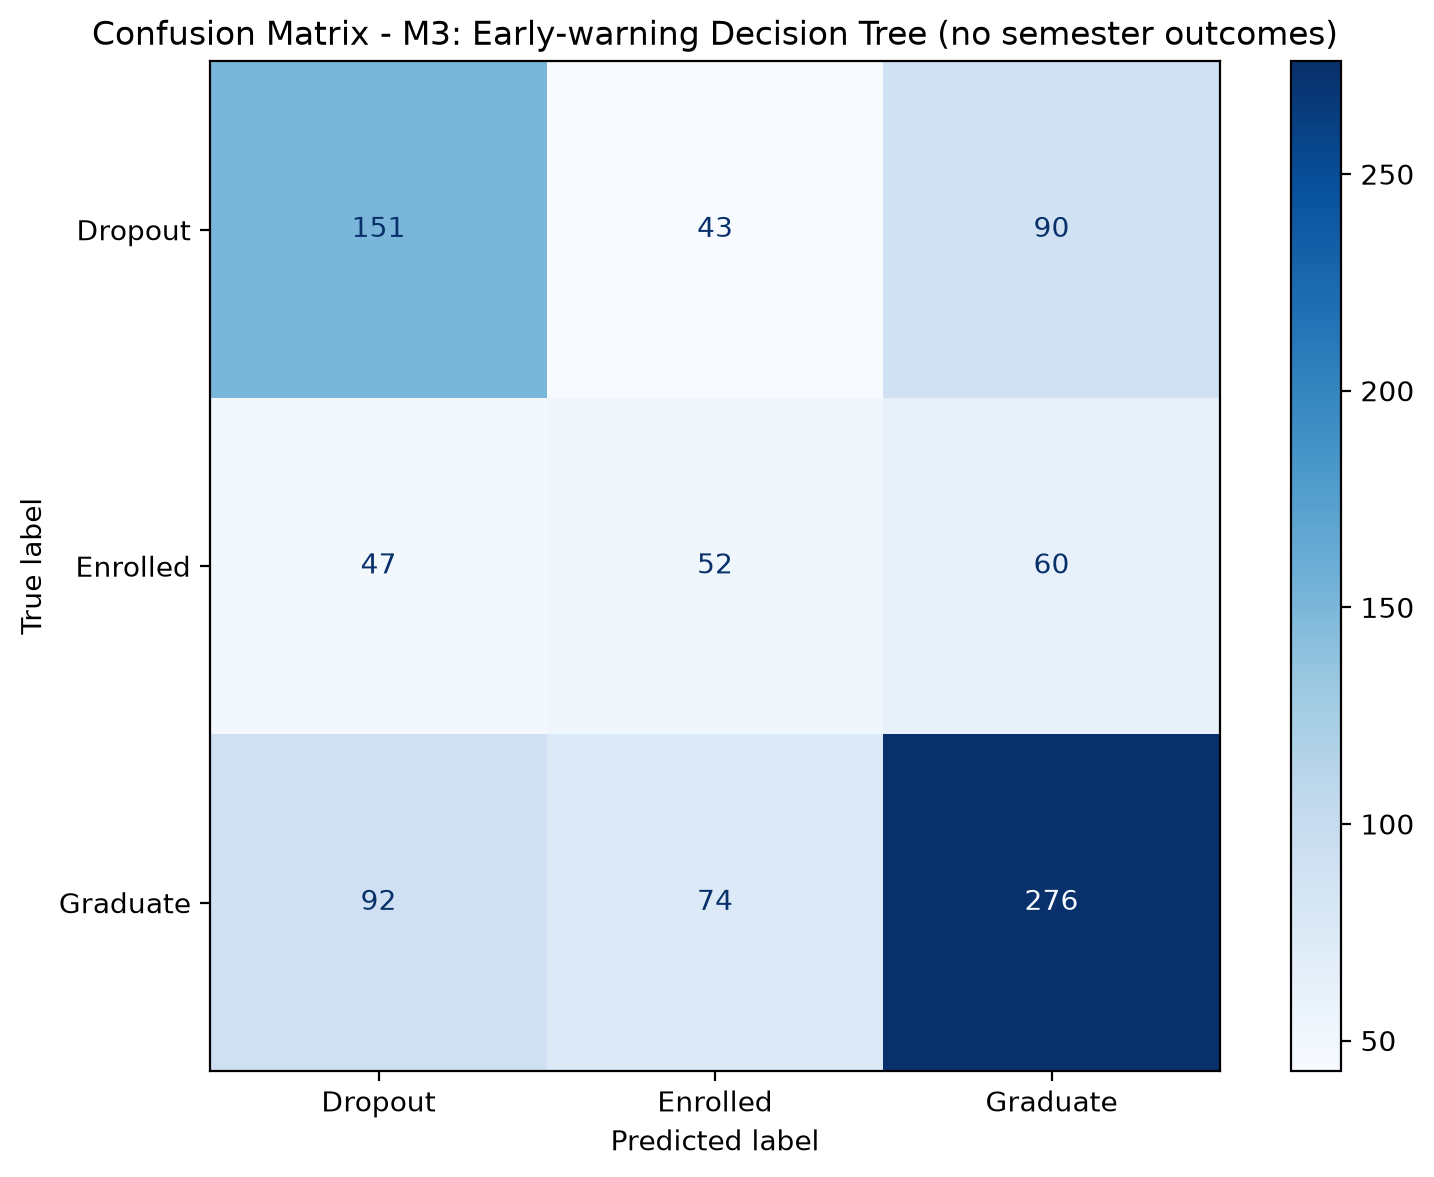

In [4]:
m3_params = {
    "criterion": "gini",
    "excluded_original_features": EARLY_WARNING_EXCLUSIONS,
    "original_feature_count": 24,
    "random_state": 42,
}
m3_report_path = OUTPUTS_DIR / "classification_report_M3.txt"
m3_cm_path = FIGURES_DIR / "E_cm_M3.png"

m3_result = evaluate_model(
    m3, X_train_m3, y_train, X_test_m3, y_test,
    model_id="M3",
    model_name="Early-warning Decision Tree (no semester outcomes)",
    params=m3_params,
    author="E",
    classification_report_path=m3_report_path,
    confusion_matrix_path=m3_cm_path,
)
display(pd.DataFrame([m3_result])[RESULT_COLUMNS])
display(Image(filename=str(m3_cm_path), width=760))

## 5. Present the modified tree

The first four levels are rendered so split names and node statistics remain legible. The display limit does not change the fitted M3 model.

Saved: D:\decisionTree\Lab2_DecisionTree\figures\E_tree_M3.png


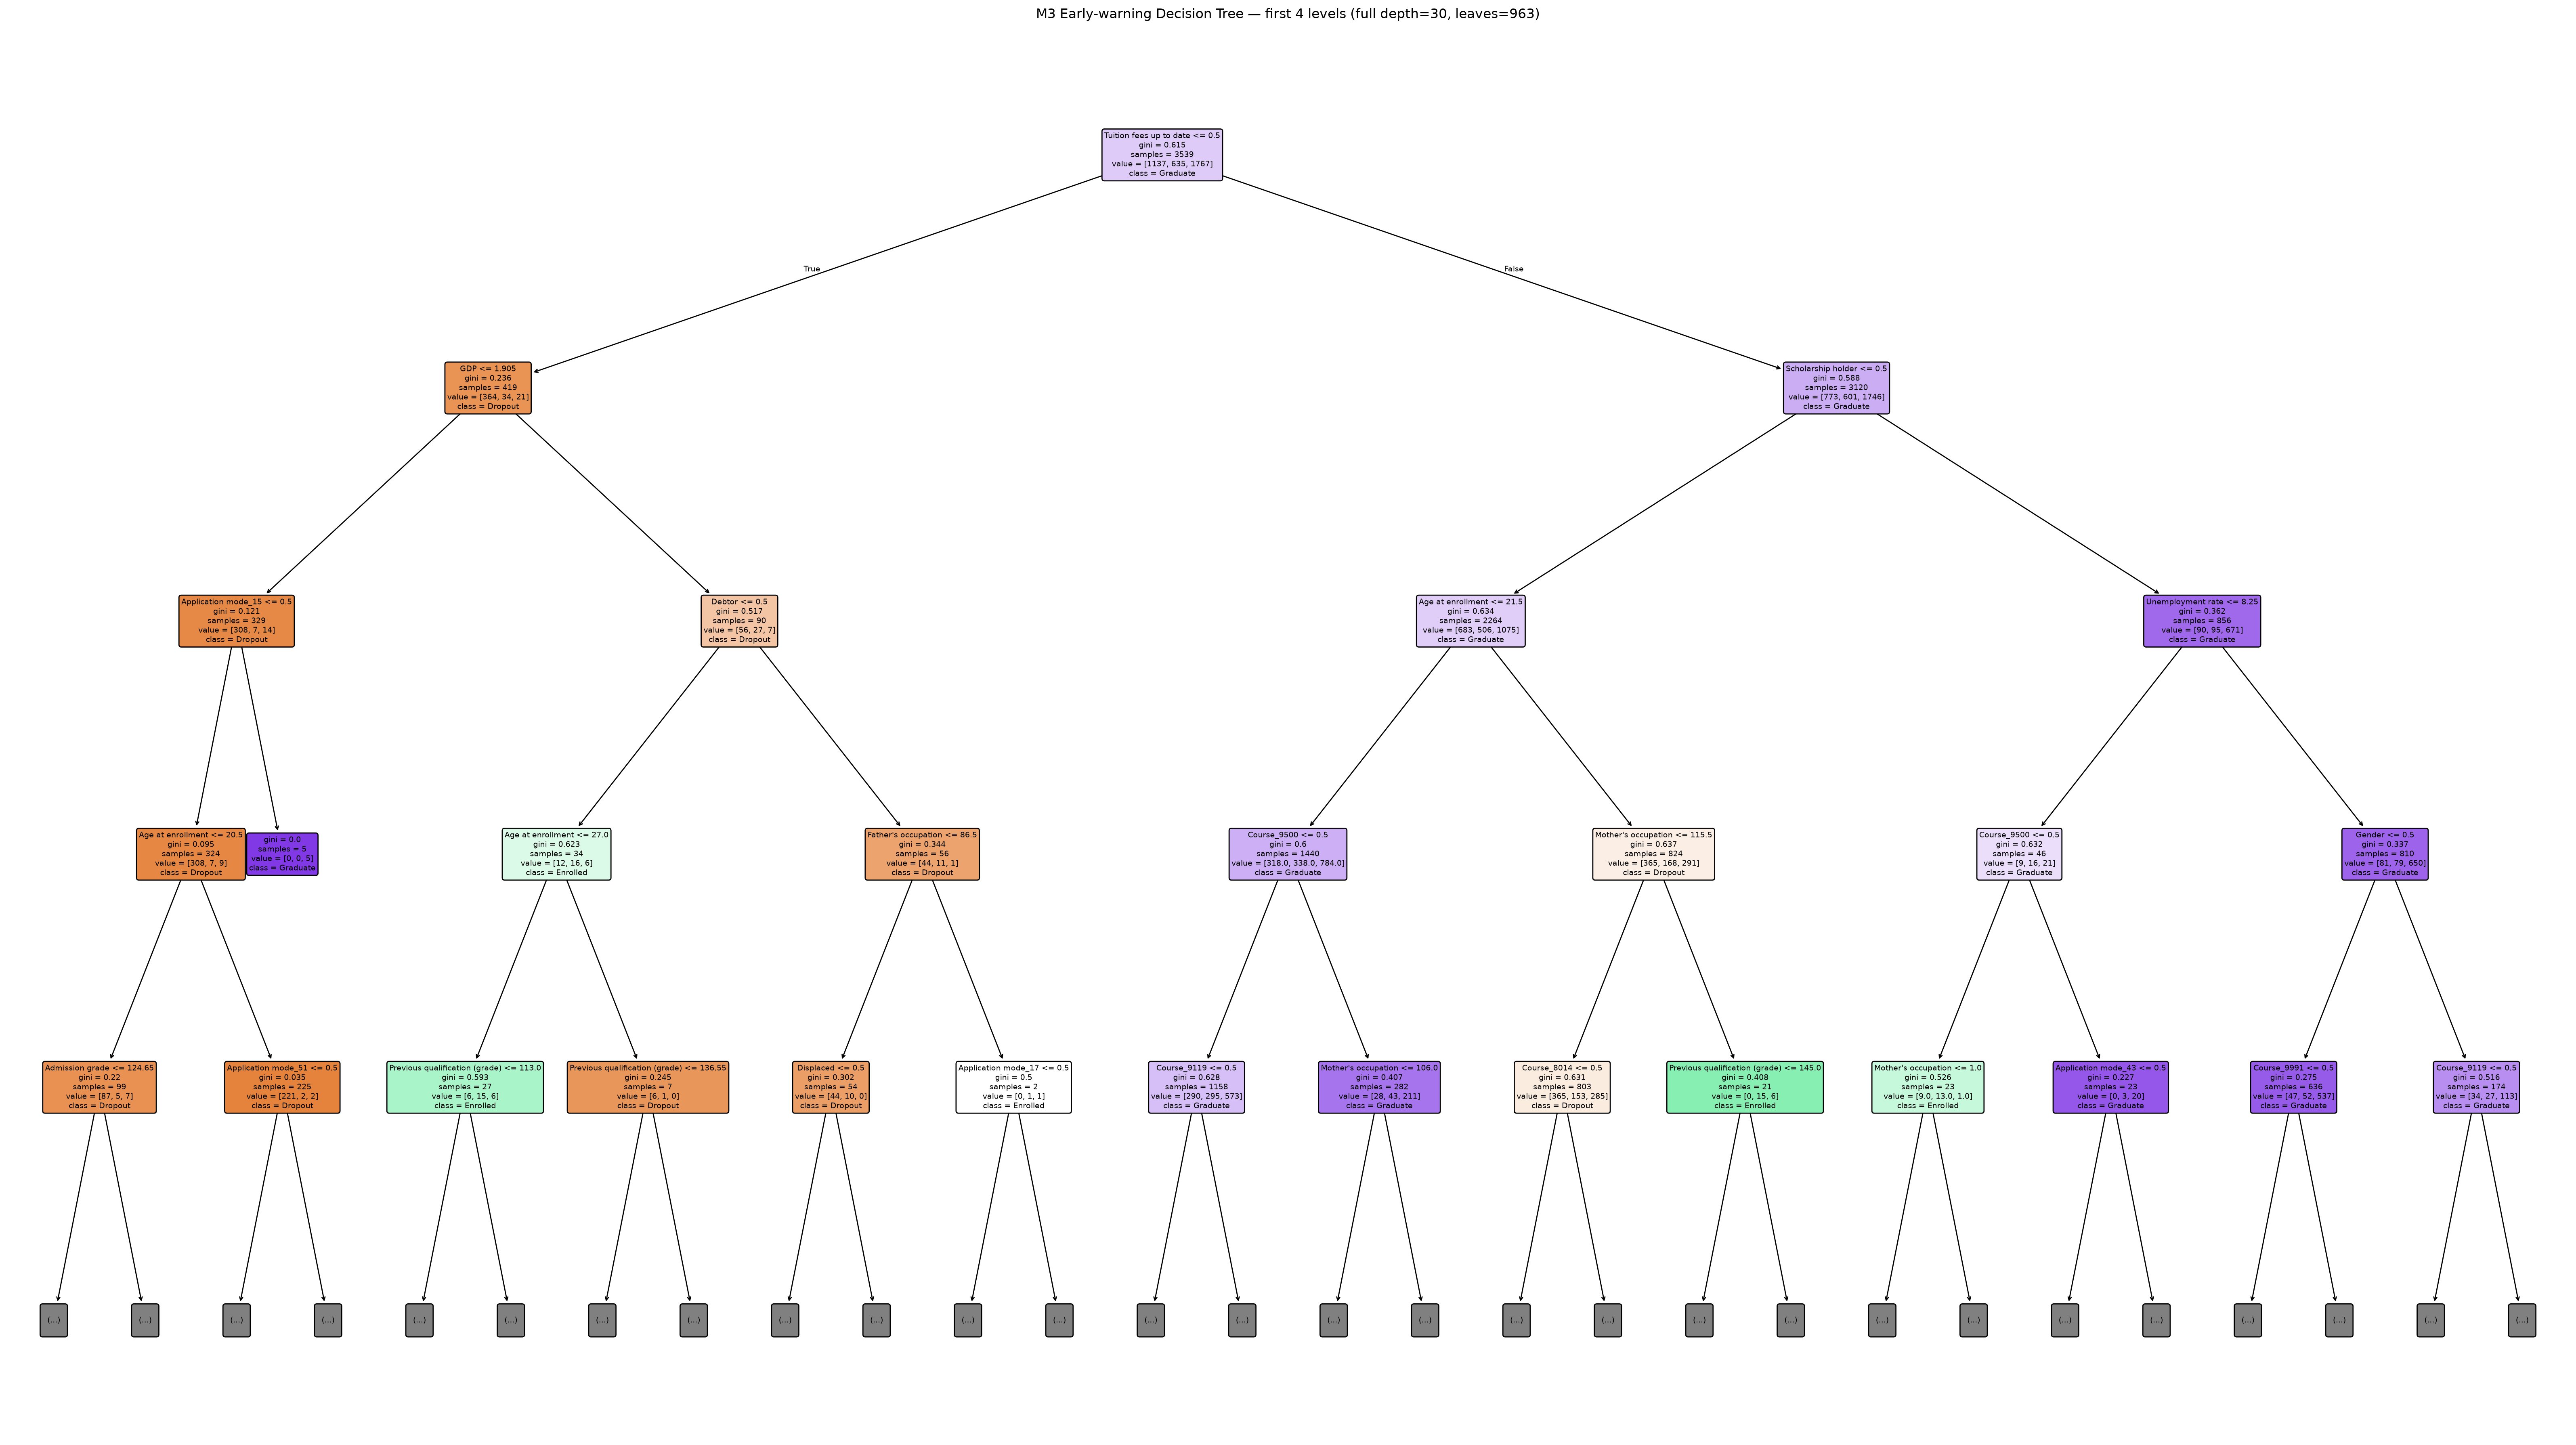

In [5]:
m3_tree_path = plot_tree_figure(
    m3, X_train_m3.columns, m3.classes_,
    FIGURES_DIR / "E_tree_M3.png",
    max_depth=4, figsize=(32, 18), dpi=200, fontsize=7,
    title=(
        "M3 Early-warning Decision Tree — first 4 levels "
        f"(full depth={m3.get_depth()}, leaves={m3.get_n_leaves()})"
    ),
)
print(f"Saved: {m3_tree_path}")
display(Image(filename=str(m3_tree_path), width=1200))

## 6. Compare feature importance: M0 versus M3

A reference M0 is refitted on the same training rows only to recover `feature_importances_`; it is not re-evaluated and no M0 row is written.

Because the shared preprocessing one-hot encodes four categorical variables, their dummy-column importances are summed back to the corresponding original UCI feature. This produces a fair, interpretable **36-original-feature M0 versus 24-original-feature M3** comparison. Both panels use the same x-axis scale.

,M0 feature,M0 importance,M3 feature,M3 importance
0,Curricular units 2nd sem (approved),0.3404,Course,0.1178
1,Curricular units 2nd sem (grade),0.0453,Admission grade,0.1129
2,Tuition fees up to date,0.0452,Tuition fees up to date,0.1116
3,Curricular units 2nd sem (enrolled),0.0450,Previous qualification (grade),0.0839
4,Admission grade,0.0444,Age at enrollment,0.0790
5,Course,0.0441,Father's occupation,0.0641
6,Curricular units 1st sem (evaluations),0.0335,Mother's occupation,0.0539
7,Previous qualification (grade),0.0308,GDP,0.0466
8,Curricular units 1st sem (approved),0.0288,Mother's qualification,0.0459
9,Mother's occupation,0.0283,Father's qualification,0.0434


M0 strongest original feature: Curricular units 2nd sem (approved) (0.3404)
M3 strongest original feature: Course (0.1178)
Saved: D:\decisionTree\Lab2_DecisionTree\figures\E_feature_importance.png
Saved: D:\decisionTree\Lab2_DecisionTree\outputs\E_feature_importance_comparison.csv


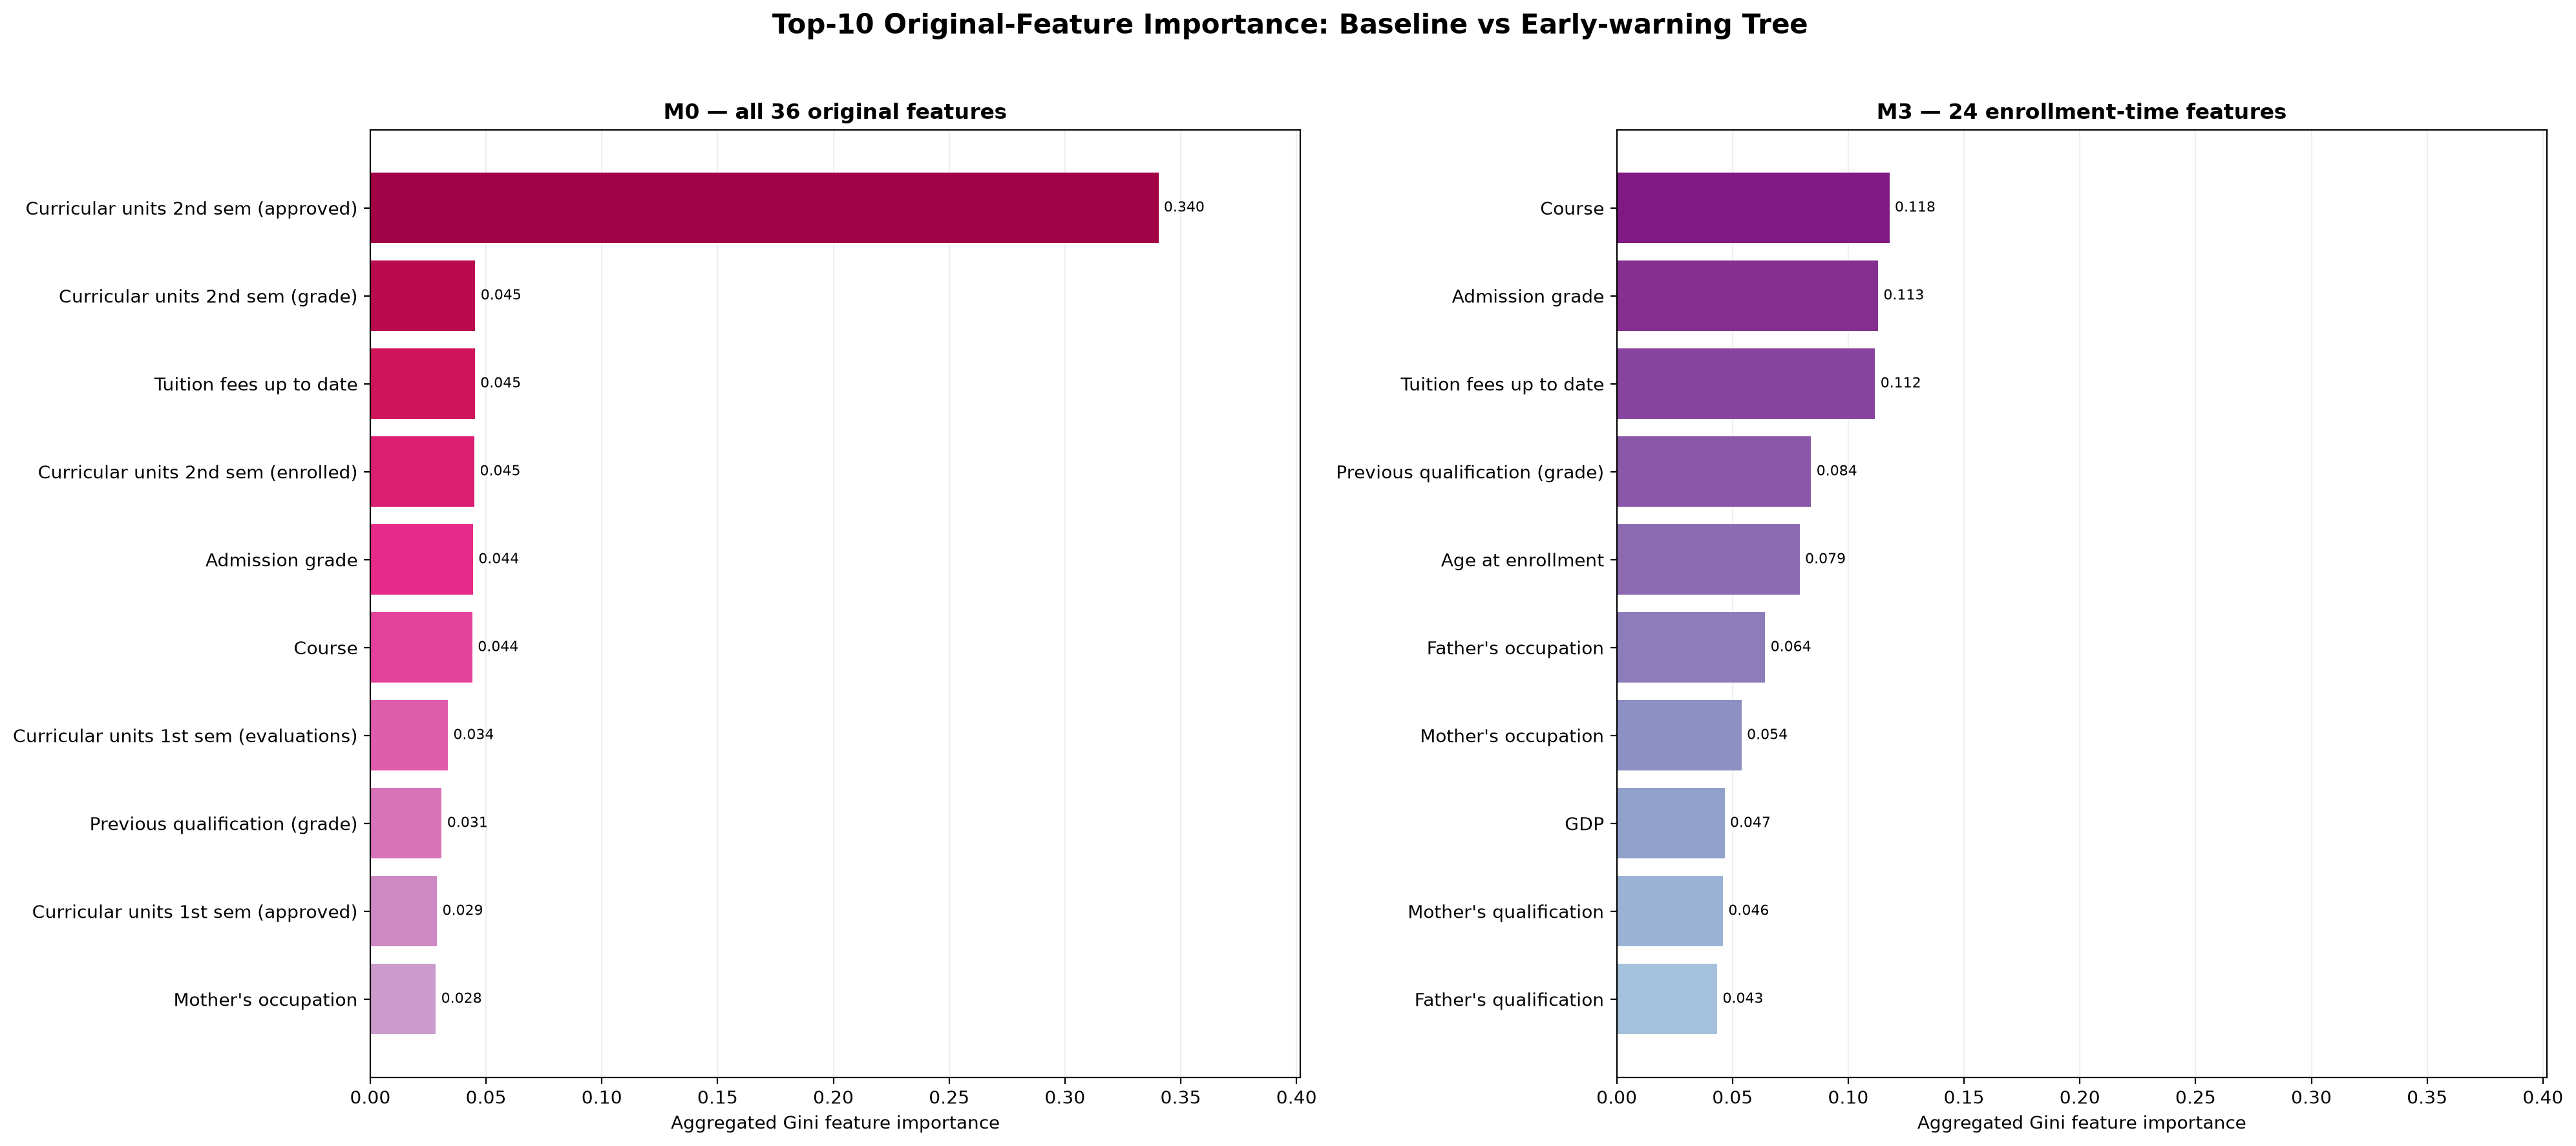

In [6]:
m0_reference = DecisionTreeClassifier(random_state=42)
m0_reference.fit(X_train, y_train)


def original_feature_name(encoded_name: str) -> str:
    """Map a shared-pipeline column back to its original UCI feature."""
    for original_name in ONE_HOT_COLS:
        if encoded_name == original_name or encoded_name.startswith(f"{original_name}_"):
            return original_name
    return encoded_name


def aggregate_original_importance(model, encoded_columns, expected_original_features):
    """Sum dummy-column Gini importances and return all expected original features."""
    encoded_importance = pd.Series(
        model.feature_importances_, index=encoded_columns, dtype=float
    )
    original_names = encoded_importance.index.map(original_feature_name)
    aggregated = encoded_importance.groupby(original_names).sum()
    return aggregated.reindex(expected_original_features, fill_value=0.0).sort_values(ascending=False)


m0_importance = aggregate_original_importance(m0_reference, X_train.columns, original_features)
m3_importance = aggregate_original_importance(m3, X_train_m3.columns, retained_original_features)

assert len(m0_importance) == 36 and len(m3_importance) == 24
assert set(m0_importance.index) == set(original_features)
assert set(m3_importance.index) == set(retained_original_features)
assert np.isclose(m0_importance.sum(), 1.0)
assert np.isclose(m3_importance.sum(), 1.0)

TOP_N = 10
top_m0 = m0_importance.head(TOP_N).sort_values()
top_m3 = m3_importance.head(TOP_N).sort_values()
common_xmax = max(float(top_m0.max()), float(top_m3.max())) * 1.18

fig, axes = plt.subplots(1, 2, figsize=(20, 9), sharex=True)
m0_colors = plt.cm.PuRd(np.linspace(0.35, 0.85, TOP_N))
m3_colors = plt.cm.BuPu(np.linspace(0.35, 0.85, TOP_N))
m0_bars = axes[0].barh(top_m0.index, top_m0.values, color=m0_colors)
m3_bars = axes[1].barh(top_m3.index, top_m3.values, color=m3_colors)
axes[0].set_title("M0 — all 36 original features", fontweight="bold")
axes[1].set_title("M3 — 24 enrollment-time features", fontweight="bold")
for axis, bars in zip(axes, (m0_bars, m3_bars)):
    axis.set_xlabel("Aggregated Gini feature importance")
    axis.set_xlim(0, common_xmax)
    axis.grid(axis="x", alpha=0.2)
    axis.set_axisbelow(True)
    axis.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
fig.suptitle(
    "Top-10 Original-Feature Importance: Baseline vs Early-warning Tree",
    fontsize=15, fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.96))
feature_importance_path = FIGURES_DIR / "E_feature_importance.png"
fig.savefig(feature_importance_path, dpi=200, bbox_inches="tight", facecolor="white")
plt.close(fig)

importance_comparison_path = OUTPUTS_DIR / "E_feature_importance_comparison.csv"
importance_comparison = pd.DataFrame(index=original_features)
importance_comparison.index.name = "original_feature"
importance_comparison["available_in_M3"] = importance_comparison.index.isin(retained_original_features)
importance_comparison["M0_importance"] = m0_importance.reindex(original_features)
importance_comparison["M3_importance"] = m3_importance.reindex(original_features)
importance_comparison["M0_rank"] = (
    importance_comparison["M0_importance"].rank(method="min", ascending=False).astype("Int64")
)
importance_comparison["M3_rank"] = (
    importance_comparison["M3_importance"].rank(method="min", ascending=False).astype("Int64")
)
importance_comparison.to_csv(importance_comparison_path, float_format="%.10f")

importance_top10 = pd.DataFrame({
    "M0 feature": m0_importance.head(TOP_N).index,
    "M0 importance": m0_importance.head(TOP_N).to_numpy(),
    "M3 feature": m3_importance.head(TOP_N).index,
    "M3 importance": m3_importance.head(TOP_N).to_numpy(),
})
display(importance_top10.round(4))
print(f"M0 strongest original feature: {m0_importance.index[0]} ({m0_importance.iloc[0]:.4f})")
print(f"M3 strongest original feature: {m3_importance.index[0]} ({m3_importance.iloc[0]:.4f})")
print(f"Saved: {feature_importance_path}")
print(f"Saved: {importance_comparison_path}")
display(Image(filename=str(feature_importance_path), width=1200))

## 7. Compare M0 and M3

The table reports predictive quality and tree complexity on the same held-out rows. Deltas are stated in percentage points where appropriate. The train–test gap is included to make the overfitting limitation of an unconstrained tree explicit.

In [7]:
results = pd.read_csv(RESULTS_PATH)
assert (results["model_id"] == "M0").sum() == 1
assert (results["model_id"] == "M3").sum() == 1

comparison_columns = [
    "train_acc", "test_acc", "error_rate", "precision_macro",
    "recall_macro", "f1_macro", "roc_auc_macro",
    "recall_dropout", "recall_enrolled", "recall_graduate",
    "tree_depth", "n_leaves",
]
comparison = (
    results.loc[results["model_id"].isin(["M0", "M3"])]
    .set_index("model_id")
    .loc[["M0", "M3"], comparison_columns]
)
display(comparison.round(4))

m0_row = comparison.loc["M0"]
m3_row = comparison.loc["M3"]
accuracy_delta = float(m3_row["test_acc"] - m0_row["test_acc"])
error_delta = float(m3_row["error_rate"] - m0_row["error_rate"])
f1_delta = float(m3_row["f1_macro"] - m0_row["f1_macro"])
m3_train_test_gap = float(m3_row["train_acc"] - m3_row["test_acc"])

print(f"M0 test accuracy: {m0_row['test_acc']:.4f}")
print(f"M3 test accuracy: {m3_row['test_acc']:.4f}")
print(f"Accuracy change (M3 - M0): {accuracy_delta:+.4f} "
      f"({accuracy_delta * 100:+.2f} percentage points)")
print(f"Error-rate change (M3 - M0): {error_delta:+.4f}")
print(f"Macro-F1 change (M3 - M0): {f1_delta:+.4f}")
print(f"M3 train-test accuracy gap: {m3_train_test_gap:.4f} "
      f"({m3_train_test_gap * 100:.2f} percentage points)")

,train_acc,test_acc,error_rate,precision_macro,recall_macro,f1_macro,roc_auc_macro,recall_dropout,recall_enrolled,recall_graduate,tree_depth,n_leaves
model_id,,,,,,,,,,,,
M0,1.0,0.6689,0.3311,0.6076,0.6093,0.6083,0.7195,0.6796,0.3836,0.7647,27,634
M3,1.0,0.5412,0.4588,0.4921,0.4944,0.4931,0.6254,0.5317,0.3270,0.6244,30,963


M0 test accuracy: 0.6689
M3 test accuracy: 0.5412
Accuracy change (M3 - M0): -0.1277 (-12.77 percentage points)
Error-rate change (M3 - M0): +0.1277
Macro-F1 change (M3 - M0): -0.1152
M3 train-test accuracy gap: 0.4588 (45.88 percentage points)


## 8. Discussion

M0 has an information advantage. Its strongest original feature is `Curricular units 2nd sem (approved)`, an outcome observed only after enrollment. Those semester variables are highly predictive, but they arrive too late for genuinely preventive enrollment-time intervention.

After removing all 12 semester outcomes, M3 shifts toward information already available at enrollment. Aggregating the one-hot columns shows `Course`, `Admission grade`, `Tuition fees up to date`, `Previous qualification (grade)`, and `Age at enrollment` among its strongest predictors. Importance is an association with this fitted sample, not a causal effect or a justification for punitive decisions.

M3 reaches perfect training accuracy but only 0.5412 test accuracy, with depth 30 and 963 leaves. This is clear evidence that the unconstrained tree overfits. It is reported transparently because the official M3 experiment must use the same untuned tree configuration as M0; pruning M3 here would mix feature removal with a second intervention.

Therefore, **the most accurate model is not automatically the most useful model for every deployment time**. M0 is preferable for later status classification; M3 is designed for earlier screening and should only support human review and student assistance.

In [8]:
print("Classification report M3:\n")
print(m3_report_path.read_text(encoding="utf-8"))

Classification report M3:

              precision    recall  f1-score   support

     Dropout     0.5207    0.5317    0.5261       284
    Enrolled     0.3077    0.3270    0.3171       159
    Graduate     0.6479    0.6244    0.6359       442

    accuracy                         0.5412       885
   macro avg     0.4921    0.4944    0.4931       885
weighted avg     0.5459    0.5412    0.5434       885



## 9. Quality gates

These checks prevent silent column mistakes, split/target changes, duplicate result rows, invalid importance aggregation, incomplete metrics, and missing deliverables.

In [9]:
final_results = pd.read_csv(RESULTS_PATH)
assert final_results.columns.tolist() == RESULT_COLUMNS
assert (final_results["model_id"] == "M3").sum() == 1
assert m3_result["author"] == "E"
assert np.isclose(m3_result["error_rate"], 1.0 - m3_result["test_acc"])
assert all(0.0 <= float(m3_result[name]) <= 1.0 for name in [
    "train_acc", "test_acc", "error_rate", "precision_macro", "recall_macro",
    "f1_macro", "roc_auc_macro", "recall_dropout", "recall_enrolled", "recall_graduate",
])

# Exact feature-removal and split-integrity checks.
assert len(EARLY_WARNING_EXCLUSIONS) == 12
assert len(retained_original_features) == 24
assert X_train_m3.shape == (3539, 78)
assert X_test_m3.shape == (885, 78)
assert X_train_m3.equals(X_train.drop(columns=EARLY_WARNING_EXCLUSIONS))
assert X_test_m3.equals(X_test.drop(columns=EARLY_WARNING_EXCLUSIONS))
assert pandas_fingerprint(X_train) == split_fingerprints["X_train"]
assert pandas_fingerprint(X_test) == split_fingerprints["X_test"]
assert pandas_fingerprint(y_train) == split_fingerprints["y_train"]
assert pandas_fingerprint(y_test) == split_fingerprints["y_test"]
assert not (set(EARLY_WARNING_EXCLUSIONS) & set(X_train_m3.columns))
assert set(MACRO_FEATURES).issubset(X_train_m3.columns)
assert "International" in X_train_m3.columns

# Every actual M3 split must use a retained column.
split_feature_indices = m3.tree_.feature[m3.tree_.feature >= 0]
used_m3_features = set(X_train_m3.columns[split_feature_indices])
assert used_m3_features.issubset(set(X_train_m3.columns))
assert used_m3_features.isdisjoint(EARLY_WARNING_EXCLUSIONS)

# M0 reference and original-feature aggregation checks.
assert m0_reference.get_depth() == int(m0_row["tree_depth"])
assert m0_reference.get_n_leaves() == int(m0_row["n_leaves"])
assert set(m0_importance.index) == set(original_features)
assert set(m3_importance.index) == set(retained_original_features)
assert np.isclose(m0_importance.sum(), 1.0)
assert np.isclose(m3_importance.sum(), 1.0)

stored_m3 = final_results.loc[final_results["model_id"] == "M3"].iloc[0]
for metric in [
    "train_acc", "test_acc", "error_rate", "precision_macro", "recall_macro",
    "f1_macro", "roc_auc_macro", "recall_dropout", "recall_enrolled", "recall_graduate",
]:
    assert np.isclose(float(stored_m3[metric]), float(m3_result[metric]))
assert int(stored_m3["tree_depth"]) == m3.get_depth()
assert int(stored_m3["n_leaves"]) == m3.get_n_leaves()

required_artifacts = [
    RESULTS_PATH,
    m3_report_path,
    m3_cm_path,
    m3_tree_path,
    feature_importance_path,
    importance_comparison_path,
]
missing_or_empty = [
    str(path) for path in required_artifacts
    if not path.is_file() or path.stat().st_size == 0
]
assert not missing_or_empty, f"Missing or empty artifacts: {missing_or_empty}"

print("PASS — exactly 12 semester features removed; 24 original features retained.")
print("PASS — shared train/test rows and targets are unchanged after filtering.")
print("PASS — M3 uses seed 42 and the complete 16-column evaluation contract.")
print("PASS — one-hot importances aggregate to 36 M0 and 24 M3 original features.")
print("PASS — tree, confusion matrix, report, importance chart, and importance CSV exist.")

PASS — exactly 12 semester features removed; 24 original features retained.
PASS — shared train/test rows and targets are unchanged after filtering.
PASS — M3 uses seed 42 and the complete 16-column evaluation contract.
PASS — one-hot importances aggregate to 36 M0 and 24 M3 original features.
PASS — tree, confusion matrix, report, importance chart, and importance CSV exist.


## Conclusion

M3 answers a different operational question from M0: it estimates risk early enough to support intervention. On the unchanged held-out test set, accuracy falls from 0.6689 (M0) to 0.5412 (M3), a decrease of 12.77 percentage points, while macro-F1 falls from 0.6083 to 0.4931. This is the measured cost of removing information that does not exist at enrollment time.

The result should be reported as a performance-versus-timeliness trade-off, not as evidence that M3 is the best overall classifier. Its large train–test gap also means it should be treated as an interpretable lab experiment rather than a production-ready decision system.

### References

1. Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). *Predict Students' Dropout and Academic Success* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
2. Realinho, V., Machado, J., Baptista, L., & Martins, M. V. (2022). Predicting Student Dropout and Academic Success. *Data, 7*(11), 146. https://doi.org/10.3390/data7110146
3. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
4. Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth.